# A/B Testing for Marketing Incrementality & Budget Allocation

This notebook uses the Hillstrom Email Marketing Dataset to frame email measurement as a randomized experiment. The emphasis is on incremental lift, attribution bias, and the budget decisions a growth data scientist would need to support.


## Executive Summary

- **Question:** Should the business keep spending on this email campaign, or is it mostly taking credit for conversions that would have happened anyway?
- **Approach:** Use a randomized holdout test to estimate true incremental lift, compare it with naive attribution, and translate the result into unit economics.
- **Decision lens:** Scale only if the campaign creates incremental value above cost.
- **Targeting lens:** Prioritize the customer segments with the strongest net value per user.


## Business Context

- The business question is whether marketing spend creates incremental value or simply takes credit for demand that would have happened anyway.
- For a growth team, the key decision is whether the channel deserves more budget, whether holdouts should continue, and which users should be prioritized first.
- This notebook treats the email campaign as a lightweight stand-in for broader growth and ads measurement problems where incrementality, unit economics, and targeting all matter.


## 1. Problem Framing

**Business question:** Does sending a marketing email create incremental conversions and revenue?

**Decision framing:** This is an experimentation and budget allocation problem. The output is not just a lift estimate. It is a recommendation on whether the campaign deserves more budget.

**Success criteria:**
- Estimate treatment versus control conversion rates clearly.
- Quantify absolute and relative lift.
- Show why naive attribution overstates impact.
- Translate results into rollout and targeting guidance.


## Design Considerations

- Use the randomized holdout as the primary source of causal evidence.
- Keep the statistics simple and readable with a two-proportion z-test.
- Use `spend` as a directional business metric, but avoid overstating ROI because cost and margin are not fully observed.
- Keep the targeting section lightweight: useful enough to inform policy, but not so complex that it distracts from the core experiment.


In [1]:
import math
from matplotlib.ticker import FuncFormatter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_theme(style='white', rc={'axes.grid': False})


## 2. Data Loading, Overview, and Inspection

- **Source:** Hillstrom Email Marketing Dataset from MineThatData. [Dataset description](https://blog.minethatdata.com/2008/03/minethatdata-e-mail-analytics-and-data.html)
- **Loading:** The notebook reads the raw CSV directly from MineThatData in the next code cell.
- **Experiment setup:** `64,000` customers who purchased within the previous `12 months`, randomized roughly `1/3` each to `Mens E-Mail`, `Womens E-Mail`, and `No E-Mail`, with outcomes tracked for `2 weeks` after the campaign.
- **Why it fits this case:** The holdout group gives a direct baseline for measuring true campaign impact.

**Experiment groups**: `segment` shows the original experiment group for each customer. `treatment` is a derived field created in this notebook from `segment`, where any email maps to treatment and `No E-Mail` maps to control.

**Outcomes**: `conversion` is the main business outcome, `spend` supports the revenue and budget view, and `visit` is a supporting behavioral metric.

**Customer features**: `history` is used for the simple segment-level targeting view, while `recency` and `channel` provide background customer context.

For the full column-level dictionary, see [data_dictionary.md](data_dictionary.md).


In [2]:
DATA_URL = 'http://www.minethatdata.com/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv'

raw_df = pd.read_csv(DATA_URL)
raw_df.columns = [col.strip().lower().replace(' ', '_') for col in raw_df.columns]
print(f'Loaded data from: {DATA_URL}')
raw_df.head()


Loaded data from: http://www.minethatdata.com/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [3]:
print(f'Rows: {raw_df.shape[0]:,}')
print(f'Columns: {raw_df.shape[1]}')
print('\nColumns:')
print(sorted(raw_df.columns.tolist()))

raw_df[['segment', 'visit', 'conversion', 'spend']].describe(include='all')


Rows: 64,000
Columns: 12

Columns:
['channel', 'conversion', 'history', 'history_segment', 'mens', 'newbie', 'recency', 'segment', 'spend', 'visit', 'womens', 'zip_code']


,segment,visit,conversion,spend
count,64000,64000.000000,64000.000000,64000.000000
unique,3,NaN,NaN,NaN
top,Womens E-Mail,NaN,NaN,NaN
freq,21387,NaN,NaN,NaN
mean,NaN,0.146781,0.009031,1.050908
std,NaN,0.353890,0.094604,15.036448
min,NaN,0.000000,0.000000,0.000000
25%,NaN,0.000000,0.000000,0.000000
50%,NaN,0.000000,0.000000,0.000000
75%,NaN,0.000000,0.000000,0.000000


## 3. Data Preparation

The main A/B test compares customers who received any email against customers who received no email. To do that, the notebook creates a derived `treatment` field from `segment`: `1` for any email and `0` for the no-email control group. This keeps the decision rule aligned with the business question: should the team send email at all?

Columns used directly in the analysis:

| Column | Meaning | Values |
|---|---|---|
| `segment` | Original experiment group | `Mens E-Mail`, `Womens E-Mail`, or `No E-Mail` |
| `treatment` | Derived treatment-versus-control flag | `1 = any email`, `0 = no-email control` |
| `conversion` | Primary business outcome | `1 = purchased`, `0 = did not purchase` |
| `visit` | Supporting behavioral outcome | `1 = visited the site`, `0 = did not visit` |
| `spend` | Revenue outcome in the post-campaign window | Dollar amount |
| `history` | Prior customer spend used for simple segmentation | Dollar amount |


In [4]:
ab_df = raw_df.copy()
ab_df['treatment'] = (ab_df['segment'] != 'No E-Mail').astype(int)
ab_df['conversion'] = ab_df['conversion'].astype(int)
ab_df['visit'] = ab_df['visit'].astype(int)
ab_df['spend'] = ab_df['spend'].astype(float)

feature_cols = [
    col for col in ab_df.columns
    if col not in {'segment', 'treatment', 'visit', 'conversion', 'spend'}
]

print('Original experiment groups in the analysis sample (a quick check that the split still looks close to the expected 2-to-1 email vs control mix):')
print(ab_df['segment'].value_counts())
ab_df.head()


Original experiment groups in the analysis sample (a quick check that the split still looks close to the expected 2-to-1 email vs control mix):
segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend,treatment
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0,1
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0,0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0,1
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0,1
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0,1


## 4. A/B Testing Analysis

The core measurement question is simple: how much higher is the conversion rate in treatment than in control?


In [5]:
summary = (
    ab_df.groupby('treatment')
    .agg(
        users=('conversion', 'size'),
        conversions=('conversion', 'sum'),
        conversion_rate=('conversion', 'mean'),
        visit_rate=('visit', 'mean'),
        revenue_per_user=('spend', 'mean'),
        total_revenue=('spend', 'sum'),
    )
    .rename(index={0: 'control', 1: 'treatment'})
)

control_cvr = summary.loc['control', 'conversion_rate']
treatment_cvr = summary.loc['treatment', 'conversion_rate']
absolute_lift = treatment_cvr - control_cvr
relative_lift = (treatment_cvr / control_cvr) - 1 if control_cvr > 0 else np.nan
incremental_revenue_per_user = (
    summary.loc['treatment', 'revenue_per_user'] - summary.loc['control', 'revenue_per_user']
)

summary_display = summary.copy()
summary_display['conversion_rate'] = (summary_display['conversion_rate'] * 100).round(2).astype(str) + '%'
summary_display['visit_rate'] = (summary_display['visit_rate'] * 100).round(2).astype(str) + '%'
summary_display['revenue_per_user'] = summary_display['revenue_per_user'].round(2)
summary_display['total_revenue'] = summary_display['total_revenue'].round(0).astype(int)
summary_display


,users,conversions,conversion_rate,visit_rate,revenue_per_user,total_revenue
treatment,,,,,,
control,21306,122,0.57%,10.62%,0.65,13908
treatment,42694,456,1.07%,16.7%,1.25,53350


In [6]:
lift_table = pd.DataFrame(
    {
        'metric': [
            'Control CVR',
            'Treatment CVR',
            'Absolute lift (pp)',
            'Relative lift',
            'Incremental revenue per user ($)',
        ],
        'value': [
            f"{control_cvr * 100:.2f}%",
            f"{treatment_cvr * 100:.2f}%",
            f"{absolute_lift * 100:.2f}",
            f"{relative_lift * 100:.1f}%",
            f"{incremental_revenue_per_user:.2f}",
        ],
    }
)
lift_table


,metric,value
0,Control CVR,0.57%
1,Treatment CVR,1.07%
2,Absolute lift (pp),0.50
3,Relative lift,86.5%
4,Incremental revenue per user ($),0.60


/tmp/ipykernel_135232/3415863968.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Control', 'Treatment'])
/tmp/ipykernel_135232/3415863968.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Control', 'Treatment'])


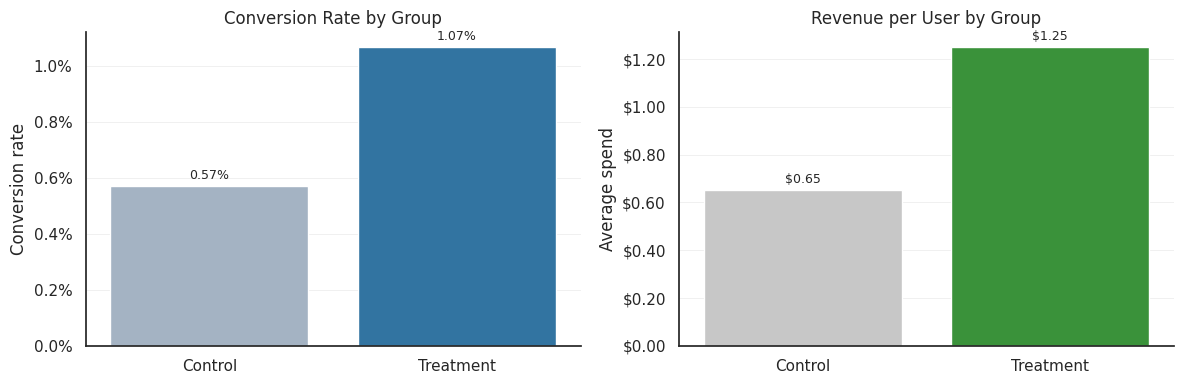

In [7]:
plot_df = summary.reset_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=plot_df, x='treatment', y='conversion_rate', ax=axes[0], hue='treatment', palette=['#9fb3c8', '#1f77b4'], legend=False)
axes[0].set_xticklabels(['Control', 'Treatment'])
axes[0].set_title('Conversion Rate by Group')
axes[0].set_ylabel('Conversion rate')
axes[0].set_xlabel('')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y * 100:.1f}%"))
axes[0].grid(axis='y', color='#d9d9d9', linewidth=0.6, alpha=0.45)
axes[0].grid(axis='x', visible=False)
for container in axes[0].containers:
    axes[0].bar_label(container, labels=[f"{bar.get_height() * 100:.2f}%" for bar in container], padding=3, fontsize=9)
sns.despine(ax=axes[0])

sns.barplot(data=plot_df, x='treatment', y='revenue_per_user', ax=axes[1], hue='treatment', palette=['#c7c7c7', '#2ca02c'], legend=False)
axes[1].set_xticklabels(['Control', 'Treatment'])
axes[1].set_title('Revenue per User by Group')
axes[1].set_ylabel('Average spend')
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"${y:.2f}"))
axes[1].grid(axis='y', color='#d9d9d9', linewidth=0.6, alpha=0.45)
axes[1].grid(axis='x', visible=False)
for container in axes[1].containers:
    axes[1].bar_label(container, labels=[f"${bar.get_height():.2f}" for bar in container], padding=3, fontsize=9)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()


What this section shows:

- Customers who received any email converted at `1.07%` versus `0.57%` in the no-email control group.
- That implies an absolute lift of about `0.50` percentage points, which is large enough to matter commercially and clears the first bar for further budget evaluation.
- Revenue per user also rises from about `$0.65` in control to `$1.25` in treatment, which is an early sign that the conversion lift may translate into real economic value.
- The next question is whether this observed lift is statistically reliable rather than noise.


## 5. Statistical Significance

A lift estimate is more useful when we know whether it is likely to reflect real signal rather than noise. The function below runs a standard two-proportion z-test on conversions, which compares the treatment and control conversion rates.

**How this is computed (technical note)**

See `References` for both an intuition-first explanation and a standard textbook treatment.

- `Observed lift = p_treatment - p_control`.
- `z = (p_treatment - p_control) / SE`, where `SE` measures how much the observed lift would typically vary from random sampling noise.
- A larger `z` means the observed gap is large relative to expected noise, which makes it harder to explain away as chance alone.
- This is a two-tailed test, so it checks for a real difference in either direction, not just whether treatment is higher than control.
- `p-value = P(|Z| >= |z|)` under the null hypothesis of no true lift. This turns the z-value into the probability of seeing a gap this large if there were actually no real effect.
- `95% CI for lift = observed lift ± 1.96 × SE`. The `1.96` means about two standard errors on either side, which is the standard way to form a 95% confidence interval.
- The z-test uses a pooled standard error under the no-effect null, while the confidence interval uses the observed group rates.


In [8]:
def two_proportion_ztest(success_t, total_t, success_c, total_c):
    p_t = success_t / total_t
    p_c = success_c / total_c
    # Pooled rate under the null hypothesis of equal conversion rates.
    pooled = (success_t + success_c) / (total_t + total_c)
    se = math.sqrt(pooled * (1 - pooled) * ((1 / total_t) + (1 / total_c)))
    z_score = (p_t - p_c) / se
    normal_cdf = 0.5 * (1 + math.erf(abs(z_score) / math.sqrt(2)))
    p_value = 2 * (1 - normal_cdf)
    # Unpooled normal-approximation confidence interval for the observed lift.
    ci_half_width = 1.96 * math.sqrt((p_t * (1 - p_t) / total_t) + (p_c * (1 - p_c) / total_c))
    return {
        'p_treatment': p_t,
        'p_control': p_c,
        'z_score': z_score,
        'p_value': p_value,
        'lift_ci_low': (p_t - p_c) - ci_half_width,
        'lift_ci_high': (p_t - p_c) + ci_half_width,
    }

ztest_result = two_proportion_ztest(
    success_t=int(summary.loc['treatment', 'conversions']),
    total_t=int(summary.loc['treatment', 'users']),
    success_c=int(summary.loc['control', 'conversions']),
    total_c=int(summary.loc['control', 'users']),
)

ztest_display = pd.Series(
    {
        'Treatment CVR': f"{ztest_result['p_treatment'] * 100:.2f}%",
        'Control CVR': f"{ztest_result['p_control'] * 100:.2f}%",
        'Z-score': round(ztest_result['z_score'], 2),
        'P-value': '<0.001' if ztest_result['p_value'] < 0.001 else f"{ztest_result['p_value']:.3f}",
        'Lift 95% CI (pp)': f"{ztest_result['lift_ci_low'] * 100:.2f} to {ztest_result['lift_ci_high'] * 100:.2f}",
    }
)

ztest_display


Treatment CVR              1.07%
Control CVR                0.57%
Z-score                     6.24
P-value                   <0.001
Lift 95% CI (pp)    0.35 to 0.64
dtype: object

What this section shows:

- The 95% confidence interval for lift is roughly `0.35` to `0.64` percentage points, which stays above zero throughout.
- The p-value is effectively zero in this sample, so the observed difference is unlikely to be random noise alone.
- Taken together, the p-value and confidence interval suggest the experiment is capturing a real positive effect rather than sampling noise.


## 6. Attribution vs Incrementality

A common mistake is to credit every treated conversion to marketing. That is closer to an attribution report than an incrementality estimate.

**How to read this table**

- Same number of users, different baseline; the difference estimates email impact.
- `Expected without email = treated users x control-group average outcome`
- Conversions use the control conversion rate, and revenue uses control revenue per user.
- `Incremental impact = treated total - expected without email`


In [9]:
naive_attributed_conversions = summary.loc['treatment', 'conversions']
expected_conversions_without_email = summary.loc['control', 'conversion_rate'] * summary.loc['treatment', 'users']
incremental_conversions = naive_attributed_conversions - expected_conversions_without_email
naive_attributed_revenue = summary.loc['treatment', 'total_revenue']
expected_revenue_without_email = summary.loc['control', 'revenue_per_user'] * summary.loc['treatment', 'users']
incremental_revenue = naive_attributed_revenue - expected_revenue_without_email

attribution_bridge_table = pd.DataFrame(
    {
        'Measurement Approach': [
            '1. Treated total (naive attribution)',
            '2. Expected without email (control baseline)',
            '3. Incremental impact',
            '4. Incremental share of treated total',
        ],
        'users': [
            f"{int(summary.loc['treatment', 'users']):,}",
            f"{int(summary.loc['treatment', 'users']):,}",
            '—',
            '—',
        ],
        'conversions': [
            f"{naive_attributed_conversions:.0f}",
            f"{expected_conversions_without_email:.0f}",
            f"{incremental_conversions:.0f}",
            f"{(incremental_conversions / naive_attributed_conversions) * 100:.1f}%",
        ],
        'revenue': [
            f"${naive_attributed_revenue:,.0f}",
            f"${expected_revenue_without_email:,.0f}",
            f"${incremental_revenue:,.0f}",
            f"{(incremental_revenue / naive_attributed_revenue) * 100:.1f}%",
        ],
    }
)

attribution_bridge_table


,Measurement Approach,users,conversions,revenue
0,1. Treated total (naive attribution),"42,694",456,"$53,350"
1,2. Expected without email (control baseline),"42,694",244,"$27,870"
2,3. Incremental impact,—,212,"$25,480"
3,4. Incremental share of treated total,—,46.4%,47.8%


What this section shows:

- Raw campaign totals can overstate impact if they credit every treated outcome to marketing.
- In this run, the naive view would credit `456` conversions and `$53,350` of revenue to email, while the control-based estimate of incremental impact is closer to `212` conversions and `$25,480`.
- That means only about `46%` of treated conversions and `48%` of treated revenue appear incremental in this experiment.
- Budget decisions should therefore use the incremental row, not the full treated total.


## 7. Unit Economics (ROI) and Budget Decision

The results show a clearly positive business case for sending email in this treatment-versus-control setup.

**Unit Economics Snapshot**

- Incremental revenue per user is about `$0.60`, calculated as treatment revenue per user minus control revenue per user (`$1.25 - $0.65`).
- Under the illustrative assumption of `$0.05` cost per send, net incremental value is about `$0.55` per user.
- That implies a break-even cost per send of roughly `$0.60` before the campaign stops being value-accretive.


In [10]:
EMAIL_COST_PER_USER = 0.05
BREAK_EVEN_COST_PER_SEND = max(incremental_revenue_per_user, 0)
net_incremental_value_per_user = incremental_revenue_per_user - EMAIL_COST_PER_USER

recommendation = 'Hold or redesign the campaign.'
if (absolute_lift > 0) and (ztest_result['p_value'] < 0.05) and (net_incremental_value_per_user > 0):
    recommendation = 'Roll out more confidently; the campaign appears incrementally positive on this assumption set.'
elif (absolute_lift > 0) and (net_incremental_value_per_user > 0):
    recommendation = 'Promising but not fully de-risked; scale carefully and keep holdouts running.'

business_table = pd.DataFrame(
    {
        'metric': [
            'Incremental revenue per user ($)',
            'Break-even cost per send ($)',
            'Assumed email cost per user ($)',
            'Net incremental value per user ($)',
        ],
        'value': [
            f"{incremental_revenue_per_user:.2f}",
            f"{BREAK_EVEN_COST_PER_SEND:.2f}",
            f"{EMAIL_COST_PER_USER:.2f}",
            f"{net_incremental_value_per_user:.2f}",
        ],
    }
)

print(recommendation)
business_table


Roll out more confidently; the campaign appears incrementally positive on this assumption set.


,metric,value
0,Incremental revenue per user ($),0.60
1,Break-even cost per send ($),0.60
2,Assumed email cost per user ($),0.05
3,Net incremental value per user ($),0.55


**Illustrative Scaling Scenarios**

The chart below shows a simple what-if view of scenario economics at larger campaign sizes.


In [11]:
scale_scenarios = pd.DataFrame({'planned_sends': [100_000, 500_000, 1_000_000]})
scale_scenarios['expected_incremental_conversions'] = scale_scenarios['planned_sends'] * absolute_lift
scale_scenarios['expected_incremental_revenue'] = scale_scenarios['planned_sends'] * incremental_revenue_per_user
scale_scenarios['projected_campaign_cost'] = scale_scenarios['planned_sends'] * EMAIL_COST_PER_USER
scale_scenarios['projected_net_value'] = (
    scale_scenarios['expected_incremental_revenue'] - scale_scenarios['projected_campaign_cost']
)
scale_scenarios['scale_recommendation'] = np.where(
    scale_scenarios['projected_net_value'] > 0,
    'Economically viable on current assumptions',
    'Do not scale on current assumptions',
)
scale_scenarios['expected_incremental_conversions'] = scale_scenarios['expected_incremental_conversions'].round(0).astype(int)
scale_scenarios['expected_incremental_revenue'] = scale_scenarios['expected_incremental_revenue'].round(0).astype(int)
scale_scenarios['projected_campaign_cost'] = scale_scenarios['projected_campaign_cost'].round(0).astype(int)
scale_scenarios['projected_net_value'] = scale_scenarios['projected_net_value'].round(0).astype(int)


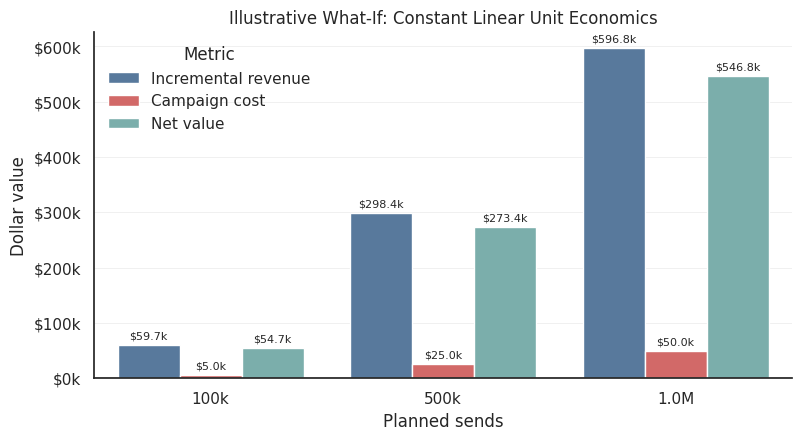

In [12]:
scale_plot = scale_scenarios[[
    'planned_sends',
    'expected_incremental_revenue',
    'projected_campaign_cost',
    'projected_net_value',
]].melt(
    id_vars='planned_sends',
    var_name='metric',
    value_name='amount',
)

metric_labels = {
    'expected_incremental_revenue': 'Incremental revenue',
    'projected_campaign_cost': 'Campaign cost',
    'projected_net_value': 'Net value',
}
scale_plot['metric'] = scale_plot['metric'].map(metric_labels)
scale_plot['planned_sends_label'] = scale_plot['planned_sends'].map({100_000: '100k', 500_000: '500k', 1_000_000: '1.0M'})

plt.figure(figsize=(9, 4.5))
ax = sns.barplot(
    data=scale_plot,
    x='planned_sends_label',
    y='amount',
    hue='metric',
    palette=['#4c78a8', '#e45756', '#72b7b2'],
)
plt.axhline(0, color='#444444', linewidth=0.9)
plt.title('Illustrative What-If: Constant Linear Unit Economics')
plt.xlabel('Planned sends')
plt.ylabel('Dollar value')
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"${y/1000:.0f}k"))
plt.grid(axis='y', color='#d9d9d9', linewidth=0.6, alpha=0.45)
plt.grid(axis='x', visible=False)
for container in ax.containers:
    ax.bar_label(container, labels=[f"${bar.get_height()/1000:.1f}k" for bar in container], padding=3, fontsize=8)
plt.legend(title='Metric', frameon=False)
sns.despine()
plt.show()


What this section shows:

- Unit economics are strongly positive (`~$0.55` net per user), supporting scale.
- Scaling remains attractive as long as cost per user stays below the break-even cost of about `$0.60`.
- If response and cost remain stable, scaling linearly increases net value. In practice, performance may weaken as the campaign expands to less responsive users.


## 8. Segment Insights: Who Should We Target First?

This section turns segment-level treatment differences into a simple targeting policy.

The four segments are derived from the `history` variable by splitting historical spend into quartiles, so each band contains roughly one quarter of customers.


In [13]:
seg_df = ab_df.copy()
history_band_labels = ['Low historical spend', 'Lower-mid historical spend', 'Upper-mid historical spend', 'High historical spend']
seg_df['history_band'] = pd.qcut(
    seg_df['history'],
    q=4,
    labels=history_band_labels,
    duplicates='drop',
)

segment_summary = (
    seg_df.groupby(['history_band', 'treatment'])
    .agg(
        users=('conversion', 'size'),
        conversions=('conversion', 'sum'),
        conversion_rate=('conversion', 'mean'),
        revenue_per_user=('spend', 'mean'),
    )
    .reset_index()
)

segment_pivot = segment_summary.pivot(index='history_band', columns='treatment')
segment_pivot.columns = [f"{metric}_{'control' if treatment == 0 else 'treatment'}" for metric, treatment in segment_pivot.columns]
segment_pivot = segment_pivot.rename(
    columns={
        'conversion_rate_control': 'control_cvr',
        'conversion_rate_treatment': 'treatment_cvr',
    }
)
segment_pivot['absolute_lift'] = segment_pivot['treatment_cvr'] - segment_pivot['control_cvr']
segment_pivot['incremental_revenue_per_user'] = (
    segment_pivot['revenue_per_user_treatment'] - segment_pivot['revenue_per_user_control']
)
segment_pivot['break_even_cost_per_send'] = segment_pivot['incremental_revenue_per_user'].clip(lower=0)
segment_pivot['net_value_per_user_at_assumed_cost'] = segment_pivot['incremental_revenue_per_user'] - EMAIL_COST_PER_USER
segment_pivot = segment_pivot.sort_index()


,priority,history_band,incremental_revenue_per_user,break_even_cost_per_send,net_value_per_user_at_assumed_cost
3,Priority 1,High historical spend,0.99,0.99,0.94
0,Priority 2,Low historical spend,0.69,0.69,0.64
2,Priority 3,Upper-mid historical spend,0.40,0.40,0.35
1,Priority 4,Lower-mid historical spend,0.30,0.30,0.25


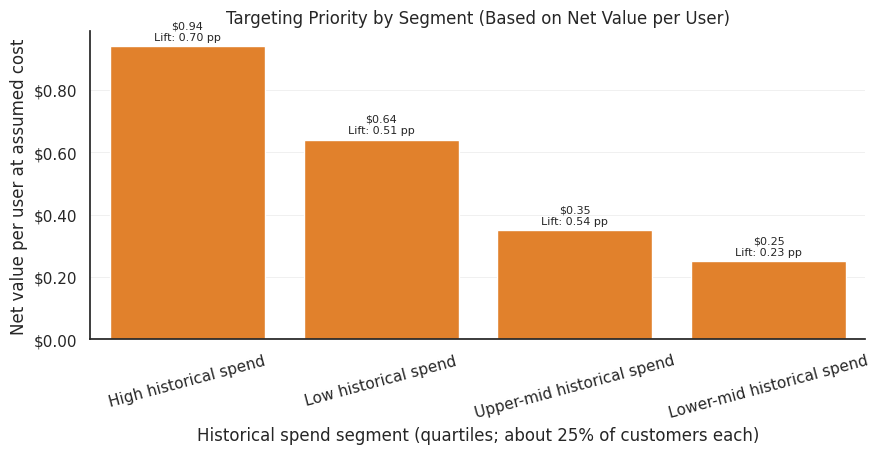

In [14]:
policy_table = (
    segment_pivot.reset_index()
    .sort_values('net_value_per_user_at_assumed_cost', ascending=False)
    [[
        'history_band',
        'incremental_revenue_per_user',
        'break_even_cost_per_send',
        'net_value_per_user_at_assumed_cost',
    ]]
)
policy_table['priority'] = [f"Priority {i}" for i in range(1, len(policy_table) + 1)]
policy_table['history_band'] = policy_table['history_band'].astype(str)
policy_table['incremental_revenue_per_user'] = policy_table['incremental_revenue_per_user'].round(2)
policy_table['break_even_cost_per_send'] = policy_table['break_even_cost_per_send'].round(2)
policy_table['net_value_per_user_at_assumed_cost'] = policy_table['net_value_per_user_at_assumed_cost'].round(2)
policy_table_display = policy_table.copy()
policy_table_display = policy_table_display[[
    'priority',
    'history_band',
    'incremental_revenue_per_user',
    'break_even_cost_per_send',
    'net_value_per_user_at_assumed_cost',
]]
policy_table_display['incremental_revenue_per_user'] = policy_table_display['incremental_revenue_per_user'].map(lambda x: f"{x:.2f}")
policy_table_display['break_even_cost_per_send'] = policy_table_display['break_even_cost_per_send'].map(lambda x: f"{x:.2f}")
policy_table_display['net_value_per_user_at_assumed_cost'] = policy_table_display['net_value_per_user_at_assumed_cost'].map(lambda x: f"{x:.2f}")
display(policy_table_display)

segment_plot = policy_table.copy()
segment_plot['lift_label_pp'] = (
    segment_pivot.reset_index()
    .sort_values('net_value_per_user_at_assumed_cost', ascending=False)['absolute_lift']
    .mul(100)
    .round(2)
    .tolist()
)

plt.figure(figsize=(10, 4))
ax = sns.barplot(data=segment_plot, x='history_band', y='net_value_per_user_at_assumed_cost', color='#ff7f0e')
plt.axhline(0, color='#444444', linewidth=0.9)
plt.title('Targeting Priority by Segment (Based on Net Value per User)')
plt.xlabel('Historical spend segment (quartiles; about 25% of customers each)')
plt.ylabel('Net value per user at assumed cost')
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"${y:.2f}"))
plt.grid(axis='y', color='#d9d9d9', linewidth=0.6, alpha=0.45)
plt.grid(axis='x', visible=False)
for container in ax.containers:
    labels = [
        f"${bar.get_height():.2f}\nLift: {lift:.2f} pp"
        for bar, lift in zip(container, segment_plot['lift_label_pp'])
    ]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)
sns.despine()
plt.xticks(rotation=15)
plt.show()


What this section shows:

- Scale from the highest-incremental-value segments first, while monitoring marginal returns.
- All segments are profitable at the assumed cost per user (`$0.05`).
- Prioritize the highest-spend segment first (`~$0.94` net value per user).
- Allocate budget primarily by net value per user, while lift remains a supporting metric.


## Key Recommendations

- **Key takeaway:** Scale the campaign with disciplined targeting and incrementality-based measurement.
- **Rollout:** Scale with holdout monitoring. Statistically significant lift supports rollout (`1.07%` CVR versus `0.57%` in control).
- **Budget rule:** Scale while incremental revenue per user (`~$0.60`) exceeds cost per send (`$0.05`), with a break-even cost cap of about `$0.60`.
- **Measurement rule:** Use incrementality as the decision metric. Naive attribution overstates impact by about `2x`; only about `46%` of conversions and `48%` of revenue appear truly incremental.
- **Targeting priority:** Prioritize the highest-value segments first. Start with the highest historical-spend segment (`~$0.94` net value per user), then expand based on marginal returns.
- **Operating risk:** Monitor and re-test at scale. Unit economics depend on cost assumptions and experiment representativeness, which may weaken as targeting expands to less responsive users.


## Limitations

- **Channel scope:** This is an email experiment, not a full ads auction, bidding, or multi-touch attribution environment.
- **Outcome definition as evaluation:** The notebook uses `spend` as a revenue outcome, not profit or contribution margin.
- **Segment confidence:** Segment-level results are directional, but lower-confidence than the main experiment result.
- **Linear scaling economics assumption:** The scaling view uses a simple linear assumption, so economics may look different in production.


## Production Considerations

- **Periodic re-measurement:** Keep a holdout or periodic experiment in place so the business can monitor whether true campaign impact stays stable over time.
- **Economics validation:** Validate cost and margin assumptions before scaling, since this notebook uses revenue and an illustrative cost-per-send input rather than full contribution profit.
- **Monitoring:** Track lift, revenue per user, and net value by segment so budget can be reallocated if performance drifts.
- **Operationalization:** Feed the results into a simple send policy: who to target, how much to spend, and when to pause or re-test.


## Potential Extensions

- **Experiment design:** Move from one binary treatment-control comparison to a fuller multi-arm experiment across mens email, womens email, and control.
- **Targeting & modeling:** Replace the simple segment-level policy with a user-level uplift model if targeting becomes the main product question.
- **Richer segmentation:** Add more customer features beyond historical spend if the business wants a more refined targeting policy.
- **Profit lens:** Extend the economics from revenue to profit or contribution margin if margin data becomes available.


## References

- [MineThatData dataset description](https://blog.minethatdata.com/2008/03/minethatdata-e-mail-analytics-and-data.html)
- [MineThatData direct CSV file](http://www.minethatdata.com/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv)
- [Khan Academy: Confidence interval for hypothesis test for difference in proportions](https://www.khanacademy.org/math/ap-statistics/xfb5d8e68%3Ainference-categorical-proportions/two-sample-z-test-proportions/v/confidence-interval-for-hypothesis-test-for-difference-in-proportions) for intuition on two-group proportion tests.
- [OpenIntro: Inference for comparing two proportions](https://openintro-ims.netlify.app/inference-two-props) for a direct treatment of two-proportion tests and confidence intervals.
